## COCA Dataset Preprocessing
Common evaluation task | PrediCT GSoC 2026 — Building and Comparing CAC Segmentation Strategies

In [1]:
import numpy as np
import pandas as pd
import nibabel as nib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import json, torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.functional import interpolate

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

In [2]:
DATA_ROOT = Path("../coca_project")
CANONICAL = DATA_ROOT / "data_canonical"
RESAMPLED = DATA_ROOT / "data_resampled"
TOTALSEG = Path("../totalseg_masks")
RESULTS = Path("../results")
OUTPUT = RESULTS / "common_task"
OUTPUT.mkdir(parents=True, exist_ok=True)

## Dataset Overview

In [3]:
scan_index = pd.read_csv(CANONICAL / "tables" / "scan_index.csv")
n_total = len(scan_index)
n_pos = (scan_index.voxels > 0).sum()
n_neg = (scan_index.voxels == 0).sum()
print(f"{n_total} scans | {n_pos} calcium-positive ({n_pos/n_total:.1%}) | {n_neg} calcium-free ({n_neg/n_total:.1%})")

787 scans | 447 calcium-positive (56.8%) | 340 calcium-free (43.2%)


/var/folders/mb/rtjsqjv500x4vsb09dr3ksxc0000gn/T/ipykernel_53679/584595908.py:19: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/mb/rtjsqjv500x4vsb09dr3ksxc0000gn/T/ipykernel_53679/584595908.py:19: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/mb/rtjsqjv500x4vsb09dr3ksxc0000gn/T/ipykernel_53679/584595908.py:20: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig(OUTPUT / "dataset_statistics.png", bbox_inches="tight")
/var/folders/mb/rtjsqjv500x4vsb09dr3ksxc0000gn/T/ipykernel_53679/584595908.py:20: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig(OUTPUT / "dataset_statistics.png", bbox_inches="tight")
/Users/shreyaschitransh/code/gsoc/PrediCT-GSoC-Eval/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.can

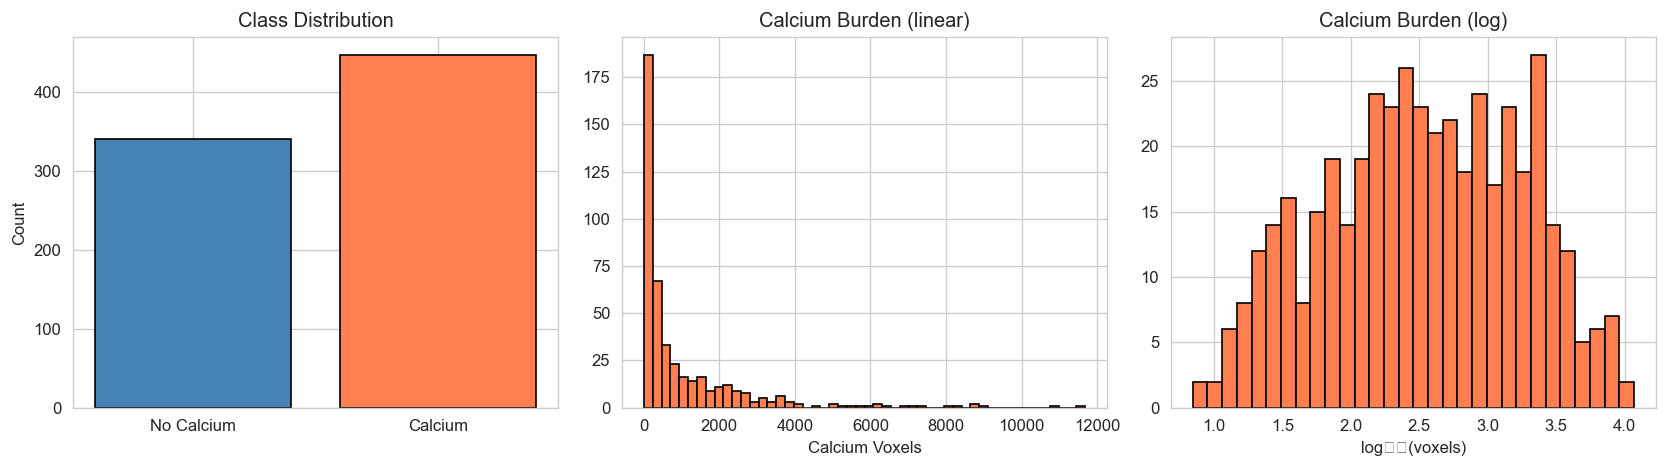

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

scan_index["has_calcium"] = scan_index.voxels > 0
counts = scan_index.has_calcium.value_counts()
axes[0].bar(["No Calcium", "Calcium"], [counts[False], counts[True]],
            color=["steelblue", "coral"], edgecolor="black")
axes[0].set_ylabel("Count")
axes[0].set_title("Class Distribution")

pos = scan_index[scan_index.voxels > 0]
axes[1].hist(pos.voxels, bins=50, edgecolor="black", color="coral")
axes[1].set_xlabel("Calcium Voxels")
axes[1].set_title("Calcium Burden (linear)")

axes[2].hist(np.log10(pos.voxels), bins=30, edgecolor="black", color="coral")
axes[2].set_xlabel("log\u2081\u2080(voxels)")
axes[2].set_title("Calcium Burden (log)")

plt.tight_layout()
plt.savefig(OUTPUT / "dataset_statistics.png", bbox_inches="tight")
plt.show()

In [5]:
def burden_category(v):
    if v == 0: return "none"
    if v < 100: return "minimal"
    if v < 1000: return "moderate"
    return "heavy"

scan_index["burden"] = scan_index.voxels.apply(burden_category)
scan_index.burden.value_counts()

burden
none        340
moderate    202
heavy       131
minimal     114
Name: count, dtype: int64

In [6]:
sample_id = "04705f6d0851"
vol = nib.load(str(RESAMPLED / sample_id / f"{sample_id}_img.nii.gz")).get_fdata()
seg = nib.load(str(RESAMPLED / sample_id / f"{sample_id}_seg.nii.gz")).get_fdata()

print(f"Volume shape: {vol.shape}")
print(f"Voxel spacing: 0.7mm isotropic (resampled)")
print(f"HU range: [{vol.min():.0f}, {vol.max():.0f}]")
print(f"Calcium voxels: {(seg > 0).sum()}")

Volume shape: (286, 286, 206)
Voxel spacing: 0.7mm isotropic (resampled)
HU range: [-1023, 2948]
Calcium voxels: 171896


## HU Windowing

Cardiac soft-tissue window (center=40, width=400 HU) maps the range [-160, 240] to [0, 1]. This captures myocardium, chamber blood pool, and fat while keeping calcium deposits (>130 HU) visible. Bone and air are clipped out — they're noise for heart segmentation.

In [7]:
def apply_hu_window(vol, center=40, width=400):
    lo, hi = center - width / 2, center + width / 2
    out = np.clip(vol, lo, hi)
    return ((out - lo) / (hi - lo)).astype(np.float32)

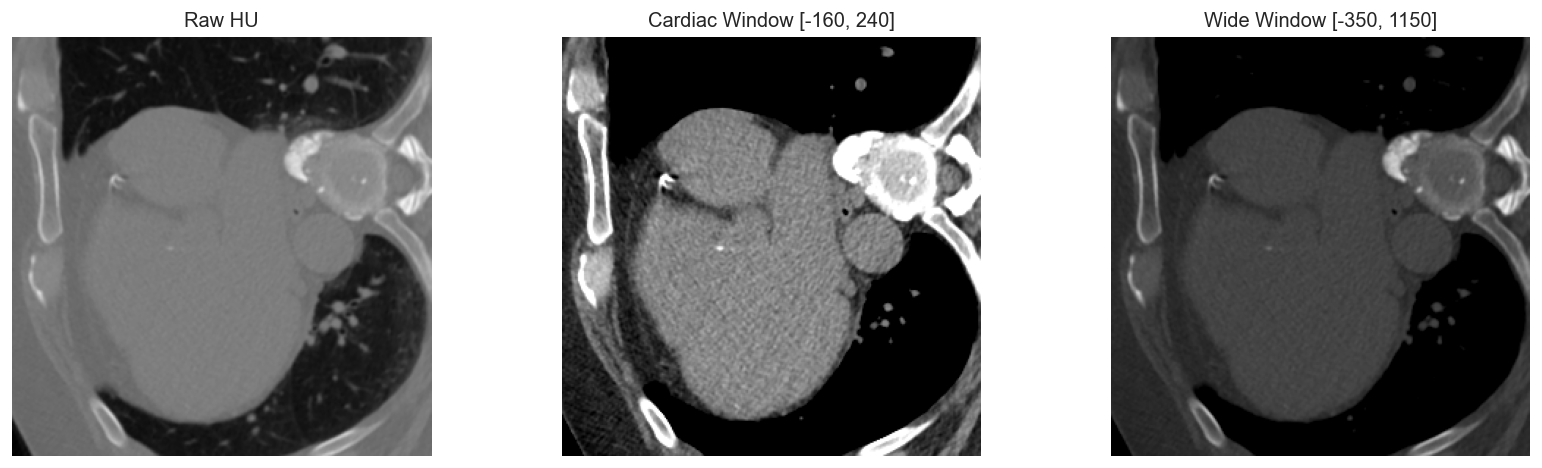

In [8]:
z = vol.shape[2] // 2

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(vol[:, :, z], cmap="gray")
axes[0].set_title("Raw HU")
axes[1].imshow(apply_hu_window(vol[:, :, z]), cmap="gray")
axes[1].set_title("Cardiac Window [-160, 240]")
axes[2].imshow(apply_hu_window(vol[:, :, z], center=400, width=1500), cmap="gray")
axes[2].set_title("Wide Window [-350, 1150]")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT / "hu_windowing.png", bbox_inches="tight")
plt.show()

## Whole-Heart Mask from TotalSegmentator

Merging all 7 cardiac structures (4 chambers, myocardium, aorta, pulmonary artery) into a single binary whole-heart mask. This serves as ground truth for the segmentation model.

In [9]:
HEART_PARTS = [
    "heart_atrium_left.nii.gz", "heart_atrium_right.nii.gz",
    "heart_myocardium.nii.gz", "heart_ventricle_left.nii.gz",
    "heart_ventricle_right.nii.gz", "aorta.nii.gz", "pulmonary_artery.nii.gz",
]

totalseg_ids = sorted([p.name for p in TOTALSEG.iterdir() if p.is_dir()])
print(f"TotalSegmentator masks: {len(totalseg_ids)} scans")

def load_heart_mask(scan_id):
    combined = None
    for part in HEART_PARTS:
        path = TOTALSEG / scan_id / part
        if not path.exists():
            continue
        arr = nib.load(str(path)).get_fdata()
        combined = arr if combined is None else np.maximum(combined, arr)
    return (combined > 0).astype(np.float32)

TotalSegmentator masks: 50 scans


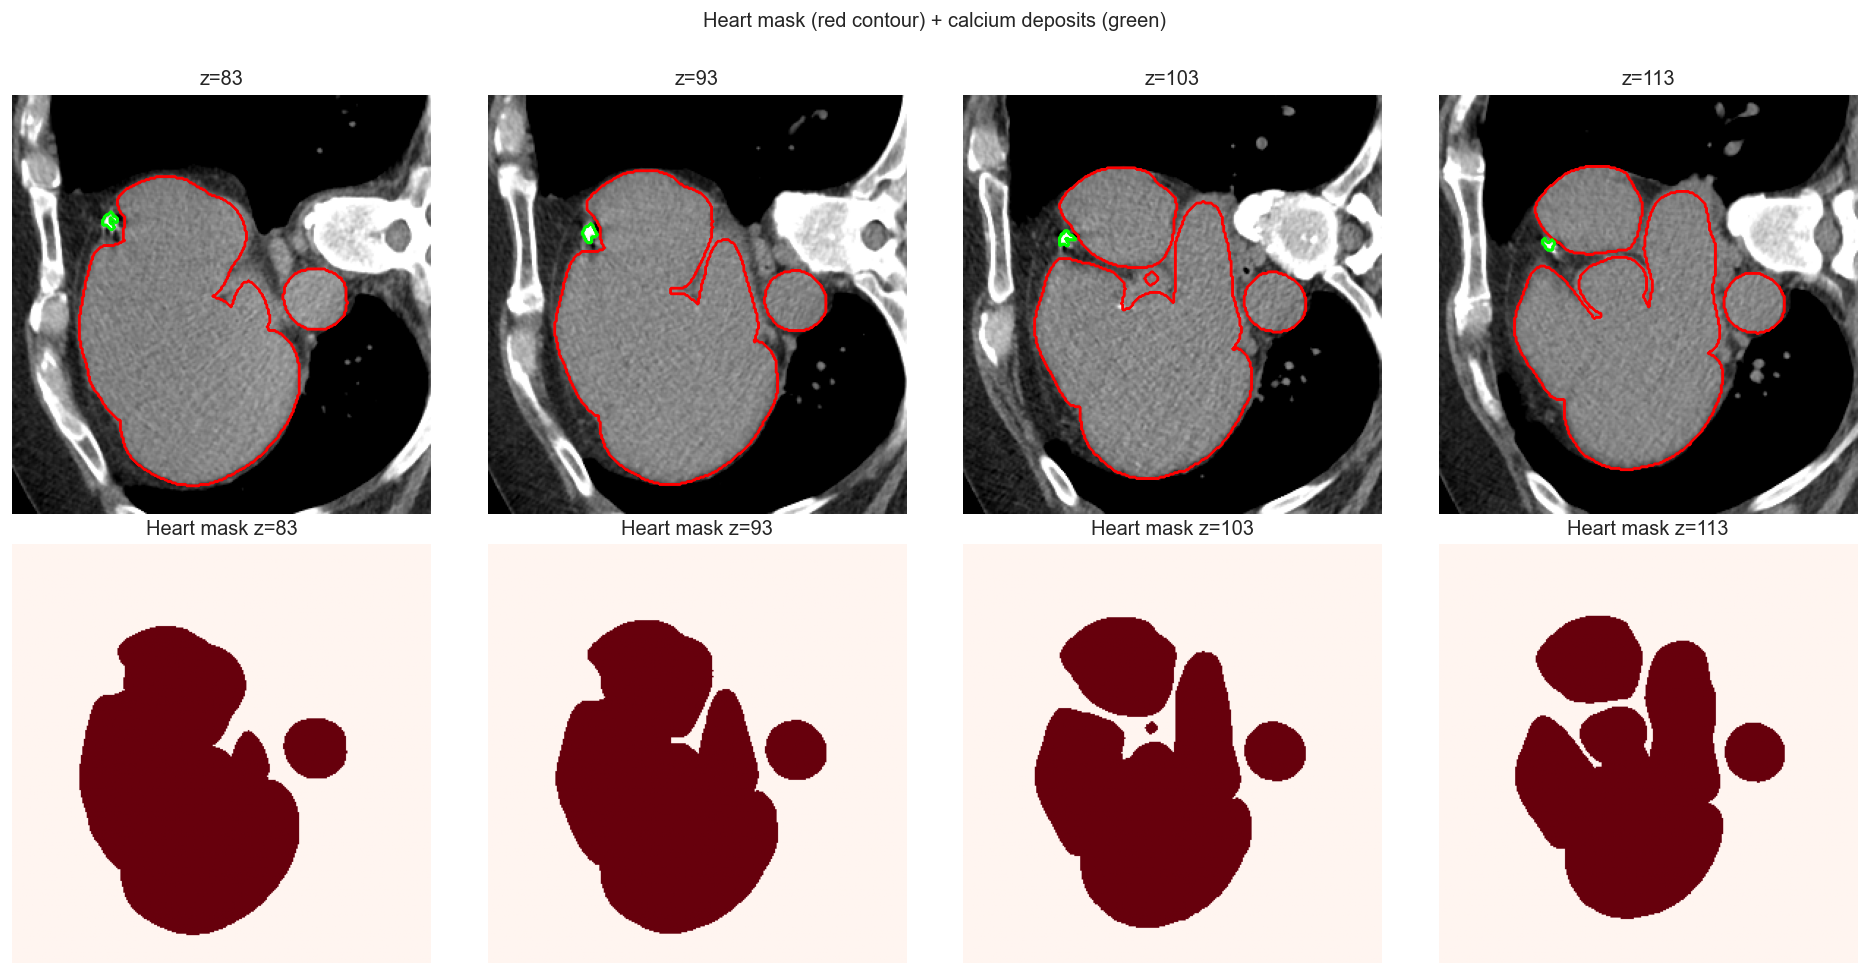

In [10]:
heart = load_heart_mask(sample_id)
calcium = nib.load(str(RESAMPLED / sample_id / f"{sample_id}_seg.nii.gz")).get_fdata()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, offset in enumerate([-20, -10, 0, 10]):
    zz = z + offset
    axes[0, i].imshow(apply_hu_window(vol[:, :, zz]), cmap="gray")
    axes[0, i].contour(heart[:, :, zz], colors="red", linewidths=0.8)
    if calcium[:, :, zz].sum() > 0:
        axes[0, i].contour(calcium[:, :, zz], colors="lime", linewidths=1)
    axes[0, i].set_title(f"z={zz}")
    axes[0, i].axis("off")

    axes[1, i].imshow(heart[:, :, zz], cmap="Reds", vmin=0, vmax=1)
    axes[1, i].set_title(f"Heart mask z={zz}")
    axes[1, i].axis("off")

plt.suptitle("Heart mask (red contour) + calcium deposits (green)", y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT / "heart_mask_overlay.png", bbox_inches="tight")
plt.show()

## Stratified Train / Val / Test Split

Volume-level split (70/15/15) stratified by calcium presence. This prevents data leakage from the same patient appearing in multiple sets.

In [11]:
selected = pd.read_csv(TOTALSEG / "selected_scans.csv")
selected["has_calcium"] = (selected.voxels > 0).astype(int)

ids = selected.scan_id.tolist()
labels = selected.has_calcium.tolist()

train_ids, temp_ids, train_y, temp_y = train_test_split(
    ids, labels, test_size=0.3, stratify=labels, random_state=42,
)
val_ids, test_ids = train_test_split(
    temp_ids, test_size=0.5, stratify=temp_y, random_state=42
)

split = {"train": train_ids, "val": val_ids, "test": test_ids}
with open(OUTPUT / "split.json", "w") as f:
    json.dump(split, f, indent=2)

for name, s_ids in split.items():
    subset = selected[selected.scan_id.isin(s_ids)]
    n_ca = subset.has_calcium.sum()
    print(f"{name:5s}: {len(s_ids):2d} scans | {n_ca} calcium+ | {len(s_ids) - n_ca} calcium-")

train: 33 scans | 21 calcium+ | 12 calcium-
val  :  7 scans | 4 calcium+ | 3 calcium-
test :  8 scans | 5 calcium+ | 3 calcium-


## Data Augmentation & DataLoader

2D axial slices resized to 256x256 for uniform batching. Only slices containing heart tissue are kept, plus 10% of background slices (hard negative mining). Augmentation: random flips + 90° rotations — cardiac CT has standardized orientation so mild geometric transforms are sufficient.

In [12]:
IMG_SIZE = 256

class HeartSegDataset(Dataset):
    def __init__(self, scan_ids, augment=False, empty_ratio=0.1):
        self.images, self.masks = [], []
        self.augment = augment

        for sid in scan_ids:
            vol = nib.load(str(RESAMPLED / sid / f"{sid}_img.nii.gz")).get_fdata()
            vol = apply_hu_window(vol)
            heart = load_heart_mask(sid)

            for z in range(vol.shape[2]):
                has_heart = heart[:, :, z].sum() > 0
                if has_heart or np.random.random() < empty_ratio:
                    self.images.append(vol[:, :, z])
                    self.masks.append(heart[:, :, z])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = torch.from_numpy(self.images[idx]).unsqueeze(0).float()
        mask = torch.from_numpy(self.masks[idx]).unsqueeze(0).float()

        img = interpolate(img.unsqueeze(0), size=IMG_SIZE, mode="bilinear",
                          align_corners=False).squeeze(0)
        mask = interpolate(mask.unsqueeze(0), size=IMG_SIZE,
                           mode="nearest").squeeze(0)

        if self.augment:
            if torch.rand(1) > 0.5:
                img, mask = img.flip(-1), mask.flip(-1)
            if torch.rand(1) > 0.5:
                img, mask = img.flip(-2), mask.flip(-2)
            k = torch.randint(0, 4, (1,)).item()
            img = torch.rot90(img, k, [-2, -1])
            mask = torch.rot90(mask, k, [-2, -1])

        return img, mask

In [13]:
train_ds = HeartSegDataset(split["train"], augment=True)
val_ds = HeartSegDataset(split["val"], augment=False)
test_ds = HeartSegDataset(split["test"], augment=False)

print(f"Train: {len(train_ds)} slices | Val: {len(val_ds)} | Test: {len(test_ds)}")

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=0)

Train: 6662 slices | Val: 1465 | Test: 1568


/Users/shreyaschitransh/code/gsoc/PrediCT-GSoC-Eval/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


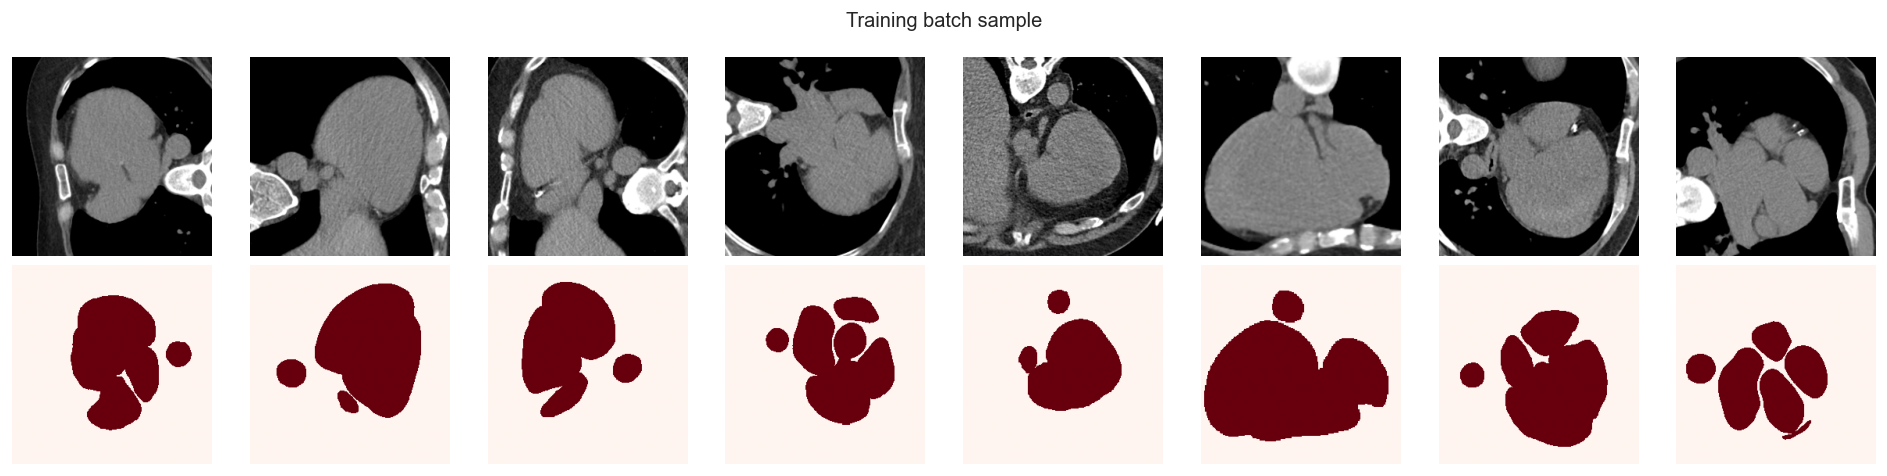

In [14]:
batch_img, batch_mask = next(iter(train_loader))

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(min(8, batch_img.size(0))):
    axes[0, i].imshow(batch_img[i, 0], cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(batch_mask[i, 0], cmap="Reds")
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("CT", rotation=0, labelpad=20)
axes[1, 0].set_ylabel("Mask", rotation=0, labelpad=20)
plt.suptitle("Training batch sample")
plt.tight_layout()
plt.savefig(OUTPUT / "batch_sample.png", bbox_inches="tight")
plt.show()

## Justification

**Pipeline design:** The COCA dataset ships as isotropic 0.7mm NIfTI volumes (resampled from original DICOM with anisotropic spacing ~0.39×0.39×3.0mm). Cardiac HU windowing [-160, 240] emphasizes the soft-tissue contrast needed for delineating heart boundaries — myocardium, blood pool, and epicardial fat — while clipping bone and air that contribute nothing to heart segmentation. TotalSegmentator's 7 per-structure masks are merged into a single binary whole-heart mask, providing ground truth that captures the full cardiac silhouette including the great vessels.

**Segmentation-specific tailoring:** The volume-level stratified split ensures calcium-positive and calcium-free scans are proportionally represented in train/val/test, preventing the model from seeing biased distributions. A 2D slice approach is chosen for computational speed — critical for a lightweight model meant to replace TotalSegmentator's slower 3D pipeline. Background slices are subsampled at 10% to address the class imbalance at the slice level (many slices above/below the heart are empty) while still training the model to correctly output zeros when appropriate. Augmentation is deliberately conservative (flips + 90° rotations) since cardiac CT has a standardized supine orientation — aggressive spatial transforms would produce anatomically unrealistic training examples.